# Challenge Sprint 3 - Estatística com Python

Integrantes: arquivo `integrantes.txt` no projeto.

Ambiente: Google Colab. Base: renda e gasto de 50 famílias.

## 1. Preparação do ambiente e carregamento da base

No Google Colab, abra este notebook e selecione **Executar tudo**. Se os arquivos do projeto não estiverem presentes, a primeira célula baixa automaticamente a base, o módulo e os testes da versão identificada do repositório. É necessário acesso à internet. A última célula executa todos os testes.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

candidatos = [Path.cwd(), *Path.cwd().parents]
candidatos += list(Path('/content').glob('*/')) if Path('/content').exists() else []
RAIZ = next((p for p in candidatos if (p / 'src/analise_estatistica.py').exists()
             and (p / 'dados/dados_familias.csv').exists()), None)
if RAIZ is None:
    # No Colab, obtém a base, o módulo e todos os testes desta versão do projeto.
    import subprocess
    import tempfile
    import shutil
    RAIZ = Path('/content/sprint3') if Path('/content').exists() else Path.cwd() / 'sprint3'
    versao = 'cccec5561bda4cf37627e7f40ef678263ff4c1b6'
    with tempfile.TemporaryDirectory() as temporario:
        checkout = Path(temporario) / 'projeto'
        subprocess.run(['git', 'clone', '--quiet',
                        'https://github.com/felipe-gallo/challenge-sprint-3-estatistica-python.git',
                        str(checkout)], check=True, timeout=120)
        subprocess.run(['git', '-C', str(checkout), 'checkout', '--quiet', versao],
                       check=True, timeout=30)
        for pasta in ['dados', 'src', 'tests']:
            shutil.copytree(checkout / pasta, RAIZ / pasta, dirs_exist_ok=True)
arquivo = RAIZ / 'dados/dados_familias.csv'

dados = pd.read_csv(arquivo)
dados.head()

,id_familia,renda_familiar,gasto_familiar
0,1,9714,3011
1,2,3728,1305
2,3,6062,1879
3,4,8845,2654
4,5,8378,2849


In [2]:
# Validação da base
colunas_obrigatorias = {'renda_familiar', 'gasto_familiar'}
assert colunas_obrigatorias.issubset(dados.columns), 'A base não possui as colunas esperadas.'
assert not dados[list(colunas_obrigatorias)].isna().any().any(), 'Há valores ausentes.'
print(f'{len(dados)} registros carregados com sucesso.')
dados[['renda_familiar', 'gasto_familiar']].describe()

50 registros carregados com sucesso.


,renda_familiar,gasto_familiar
count,50.000000,50.000000
mean,6065.500000,2011.120000
std,2707.187812,817.214648
min,1069.000000,353.000000
25%,3516.500000,1362.250000
50%,6363.000000,2127.000000
75%,8381.750000,2675.750000
max,9997.000000,3302.000000


## 2. Probabilidade acima da mediana
Assumimos que o gasto familiar segue uma Distribuição Normal com média e desvio padrão estimados pela amostra. Calculamos `P(X > mediana)` com a função de sobrevivência `norm.sf`.

In [3]:
def classificar_evento(probabilidade):
    if not 0 <= probabilidade <= 1:
        raise ValueError('A probabilidade deve estar entre 0 e 1.')
    if probabilidade <= 0.05:
        return 'raro'
    if probabilidade <= 0.25:
        return 'pouco provável'
    if probabilidade <= 0.75:
        return 'provável'
    return 'quase certo'

gastos = dados['gasto_familiar']
media = gastos.mean()
mediana = gastos.median()
desvio = gastos.std(ddof=1)
prob_acima_mediana = norm.sf(mediana, loc=media, scale=desvio)

print(f'Mediana: R$ {mediana:,.2f}')
print(f'P(X > mediana): {prob_acima_mediana:.2%}')
print(f'Classificação: {classificar_evento(prob_acima_mediana)}')

Mediana: R$ 2,127.00
P(X > mediana): 44.36%
Classificação: provável


**Interpretação:** a probabilidade calculada é aproximadamente 44,36%, portanto o evento é classificado como **provável**. O resultado não é exatamente 50% porque foi usada a mediana amostral como ponto de corte em uma Normal parametrizada pela média e pelo desvio padrão amostrais.

## 3. Probabilidade no intervalo média ± 2s
O intervalo é calculado por `[média − 2s, média + 2s]`. A probabilidade resulta da diferença entre as probabilidades acumuladas nos dois limites.

In [4]:
limite_inferior = media - 2 * desvio
limite_superior = media + 2 * desvio
prob_intervalo = (
    norm.cdf(limite_superior, loc=media, scale=desvio)
    - norm.cdf(limite_inferior, loc=media, scale=desvio)
)

print(f'Média: R$ {media:,.2f}')
print(f'Desvio padrão amostral: R$ {desvio:,.2f}')
print(f'Intervalo: [R$ {limite_inferior:,.2f}; R$ {limite_superior:,.2f}]')
print(f'Probabilidade: {prob_intervalo:.2%}')
print(f'Classificação: {classificar_evento(prob_intervalo)}')

Média: R$ 2,011.12
Desvio padrão amostral: R$ 817.21
Intervalo: [R$ 376.69; R$ 3,645.55]
Probabilidade: 95.45%
Classificação: quase certo


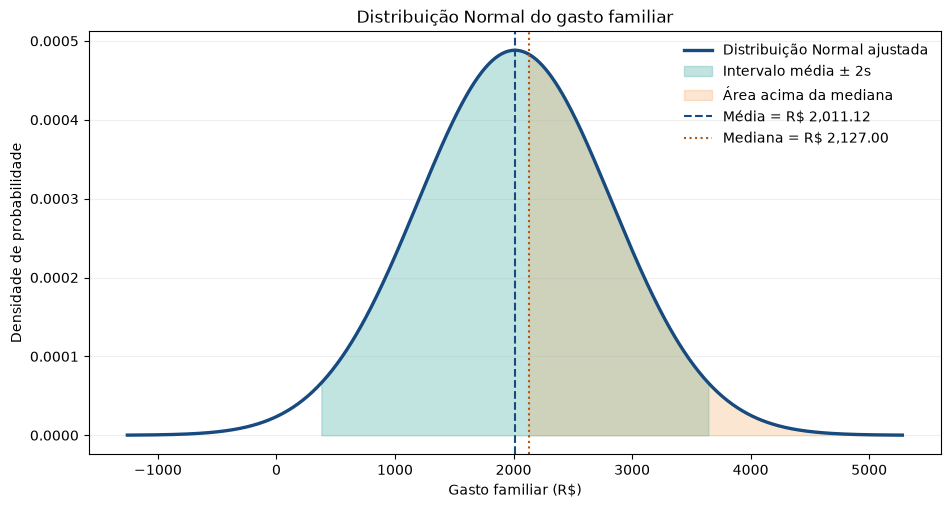

In [5]:
eixo_x = np.linspace(media - 4 * desvio, media + 4 * desvio, 800)
densidade = norm.pdf(eixo_x, loc=media, scale=desvio)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(eixo_x, densidade, color='#174A7E', linewidth=2.4, label='Distribuição Normal ajustada')
ax.fill_between(eixo_x, densidade, where=(eixo_x >= limite_inferior) & (eixo_x <= limite_superior), color='#5CB8B2', alpha=0.38, label='Intervalo média ± 2s')
ax.fill_between(eixo_x, densidade, where=eixo_x >= mediana, color='#F2A65A', alpha=0.28, label='Área acima da mediana')
ax.axvline(media, color='#174A7E', linestyle='--', label=f'Média = R$ {media:,.2f}')
ax.axvline(mediana, color='#B45309', linestyle=':', label=f'Mediana = R$ {mediana:,.2f}')
ax.set(title='Distribuição Normal do gasto familiar', xlabel='Gasto familiar (R$)', ylabel='Densidade de probabilidade')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.2)
plt.show()

**Interpretação:** cerca de 95,45% dos valores da Normal estão entre R$ 376,69 e R$ 3.645,55. Por superar 75%, esse evento é classificado como **quase certo**.

## 4. Regressão Linear Simples
O modelo estima o gasto familiar (variável dependente) a partir da renda familiar (variável explicativa).

In [6]:
X = dados[['renda_familiar']]
y = dados['gasto_familiar']
modelo = LinearRegression().fit(X, y)
previsoes = modelo.predict(X)
intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]
r2 = r2_score(y, previsoes)
rmse = np.sqrt(mean_squared_error(y, previsoes))

print(f'Equação: gasto = {intercepto:.4f} + {coeficiente:.4f} × renda')
print(f'R²: {r2:.4f}')
print(f'RMSE: R$ {rmse:,.2f}')

Equação: gasto = 207.9033 + 0.2973 × renda
R²: 0.9699
RMSE: R$ 140.36


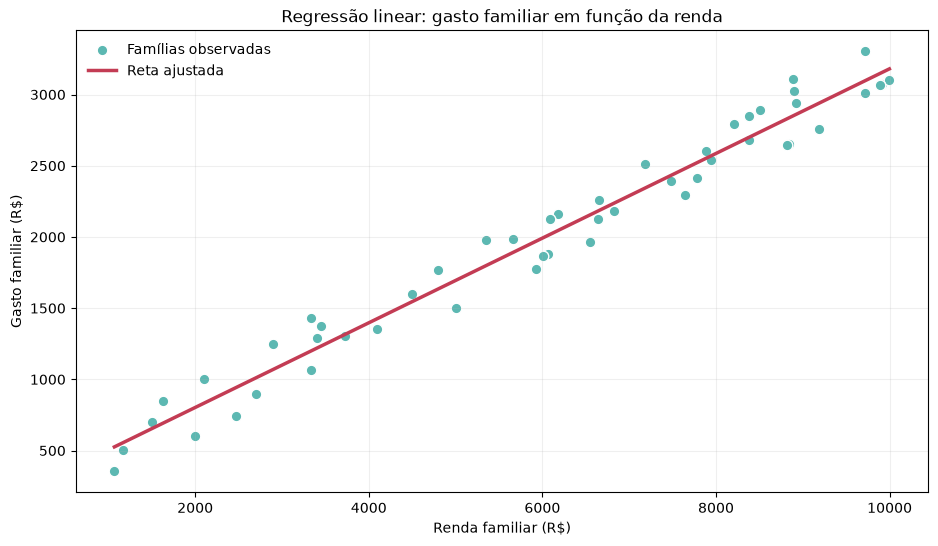

In [7]:
ordem = np.argsort(dados['renda_familiar'].to_numpy())
x_ordenado = dados['renda_familiar'].to_numpy()[ordem]
x_previsao = pd.DataFrame({'renda_familiar': x_ordenado})
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(X['renda_familiar'], y, color='#5CB8B2', edgecolor='white', s=58, label='Famílias observadas')
ax.plot(x_ordenado, modelo.predict(x_previsao), color='#C33C54', linewidth=2.5, label='Reta ajustada')
ax.set(title='Regressão linear: gasto familiar em função da renda', xlabel='Renda familiar (R$)', ylabel='Gasto familiar (R$)')
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

### Interpretação dos coeficientes

- **Intercepto (207,9033):** gasto estimado pelo modelo quando a renda é zero. É o ponto matemático em que a reta cruza o eixo vertical e deve ser interpretado com cautela, pois a amostra não contém renda igual a zero.
- **Coeficiente angular (0,2973):** para cada aumento de R$ 1,00 na renda, o gasto familiar esperado aumenta cerca de R$ 0,2973. De modo equivalente, R$ 1.000 adicionais de renda estão associados a aproximadamente R$ 297,29 adicionais de gasto.
- **R² (0,9699):** cerca de 96,99% da variação observada nos gastos é explicada linearmente pela renda nesta amostra. A associação não prova causalidade.
- **RMSE (R$ 140,36):** o erro típico das previsões dentro da amostra é de aproximadamente R$ 140,36.

## 5. Conclusão
A estatística descritiva e a Distribuição Normal quantificaram a chance dos eventos definidos no enunciado. A regressão linear transformou a relação entre renda e gasto em um modelo preditivo interpretável. Juntas, essas técnicas mostram como a estatística sustenta o aprendizado de máquina: primeiro descrevemos a incerteza dos dados e depois estimamos uma relação capaz de produzir previsões.

## Referências
- Alura. *Cálculo da probabilidade da distribuição normal com quaisquer valores de média e desvio padrão*.
- Alura. *Estatística com Python: Correlação e Regressão*.

## 6. Testes completos

Executa todos os testes em `tests/` e verifica os resultados produzidos pelas células acima. Uma falha interrompe a execução.

In [8]:
import sys
import unittest
import importlib.util

sys.path.insert(0, str(RAIZ / 'src'))
from analise_estatistica import calcular_probabilidades, ajustar_regressao

class TestNotebook(unittest.TestCase):
    def test_base(self):
        self.assertEqual(len(dados), 50)
        self.assertFalse(dados[['renda_familiar', 'gasto_familiar']].isna().any().any())

    def test_estatisticas(self):
        self.assertAlmostEqual(media, 2011.12, places=2)
        self.assertAlmostEqual(mediana, 2127.0, places=2)
        self.assertAlmostEqual(desvio, 817.215, places=2)

    def test_probabilidades(self):
        self.assertAlmostEqual(prob_acima_mediana, 0.443619, places=5)
        self.assertAlmostEqual(prob_intervalo, 0.954499736, places=8)
        self.assertEqual(classificar_evento(prob_acima_mediana), 'provável')
        self.assertEqual(classificar_evento(prob_intervalo), 'quase certo')

    def test_limites_classificacao(self):
        for valor, esperado in [(0, 'raro'), (0.05, 'raro'),
                                (0.050001, 'pouco provável'), (0.25, 'pouco provável'),
                                (0.250001, 'provável'), (0.75, 'provável'),
                                (0.750001, 'quase certo'), (1, 'quase certo')]:
            with self.subTest(valor=valor):
                self.assertEqual(classificar_evento(valor), esperado)
        for valor in [-0.01, 1.01, float('nan')]:
            with self.subTest(valor=valor), self.assertRaises(ValueError):
                classificar_evento(valor)

    def test_regressao(self):
        self.assertAlmostEqual(intercepto, 207.9033, places=3)
        self.assertAlmostEqual(coeficiente, 0.2973, places=3)
        self.assertAlmostEqual(r2, 0.9699, places=3)
        self.assertAlmostEqual(rmse, 140.36, places=2)
        np.testing.assert_allclose(previsoes, intercepto + coeficiente * X['renda_familiar'])

    def test_consistencia_com_modulo(self):
        probs = calcular_probabilidades(dados)
        _, metricas = ajustar_regressao(dados)
        self.assertAlmostEqual(prob_acima_mediana, probs['probabilidade_acima_mediana'])
        self.assertAlmostEqual(prob_intervalo, probs['probabilidade_intervalo_2s'])
        self.assertAlmostEqual(r2, metricas['r_quadrado'])
        self.assertAlmostEqual(rmse, metricas['rmse'])

suite = unittest.defaultTestLoader.discover(str(RAIZ / 'tests'), pattern='test_*.py')
if suite.countTestCases() == 0:
    raise RuntimeError('Nenhum teste do projeto foi encontrado.')
suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestNotebook))
resultado_testes = unittest.TextTestRunner(stream=sys.stdout, verbosity=2).run(suite)
if not resultado_testes.wasSuccessful():
    raise AssertionError('A suíte apresentou falhas; confira a saída acima.')
print(f'Testes completos: {resultado_testes.testsRun} aprovados, sem falhas.')


test_base_tem_50_registros (test_analise_estatistica.TestAnaliseEstatistica.test_base_tem_50_registros) ... 

ok


test_classificacao_rejeita_probabilidade_invalida (test_analise_estatistica.TestAnaliseEstatistica.test_classificacao_rejeita_probabilidade_invalida) ... 

ok


test_probabilidade_acima_mediana (test_analise_estatistica.TestAnaliseEstatistica.test_probabilidade_acima_mediana) ... 

...

ok


test_regressao (__main__.TestNotebook.test_regressao) ... 

ok


----------------------------------------------------------------------
Ran 11 tests in 0.037s

OK


Testes completos: 11 aprovados, sem falhas.
